In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from concept_abstraction.plotting import *
from concept_abstraction.utils import *

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [4]:
style_size = 'paper'

## New Plots

In [5]:
training_times = {
    'cart_pole': 4_000_000,
    'mini_grid': 500_000,
    'glucose': 4_000_000,
    'pong': 15_000_000,
    'boxing': 15_000_000,
}

gold_timesteps = {
    'cart_pole': 4_000_000,
    'mini_grid': 1_000_000,
    'glucose': 4_000_000,
    'pong': 15_000_000,
    'boxing': 30_000_000,
}

name_to_nice = {
    'cart_pole': "CartPole",
    'mini_grid': "MiniGrid",
    'glucose': 'Glucose',
    'pong': "Pong",
    'boxing': "Boxing"
}

methods_to_nice = {
    'random': 'Random',
    'entropy': 'Entropy',
    'greedy': 'Greedy',
    'lp_hybrid': "LP",
}

methods_dict = {
    0: 'Random',
    1: 'Entropy',
    2: 'Greedy',
    3: 'LP',
    
}

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

method_scales = [lambda d: d/500*100, lambda d: d/1*100, lambda d: (d+21)/42*100, lambda d: d/100*100, lambda d: (d+20)/(55+20)*100]

In [14]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["perfect_concepts","random","entropy","greedy","policy_selection_lp"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["imperfect_concepts","random","entropy","greedy","lp_hybrid"]

all_performances_perfect = []
all_performances_imperfect = []

all_baselines = []

for j,e in enumerate(perfect_environments):
    temp = []
    for m in perfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'perfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        print("Perfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])

        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)
    all_performances_perfect.append(temp)

for j,e in enumerate(imperfect_environments):
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        
        print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])
        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)

        if m == 'multiple':
            print("Environment",e,[i['concept_accuracy'] for i in matching_params])

    all_performances_imperfect.append(temp)

for j,e in enumerate(imperfect_environments):
    matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],'gold_timesteps': gold_timesteps[e],
                                                                'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison', 'method': 'ground_truth'})
    m = 'ground_truth'
    print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed']) for i in matching_params if m in i])
    performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
    all_baselines.append(performance)
all_baselines.append(0)

Perfect cart_pole perfect_concepts 3 [(499.5, 42, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.875, 44, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.915, 43, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])]
Perfect cart_pole random 3 [(173.9106830122592, 44, [0, 9, 10]), (171.32413793103447, 42, [0, 9, 10]), (172.8411867364747, 43, [0, 9, 10])]
Perfect cart_pole entropy 3 [(104.6621052631579, 44, [3, 0, 9]), (105.5270413573701, 42, [3, 0, 9]), (106.8741935483871, 43, [3, 0, 9])]
Perfect cart_pole greedy 3 [(164.65671641791045, 44, [9, 10, 11]), (163.0935960591133, 43, [9, 10, 11]), (167.53807106598984, 42, [9, 10, 11])]
Perfect cart_pole policy_selection_lp 3 [(330.0816326530612, 44, [4, 6, 7]), (450.79245283018867, 43, [4, 6, 7]), (440.56363636363636, 42, [3, 6, 7])]
Perfect mini_grid perfect_concepts 3 [(0.9595455418019246, 43, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 4

4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1


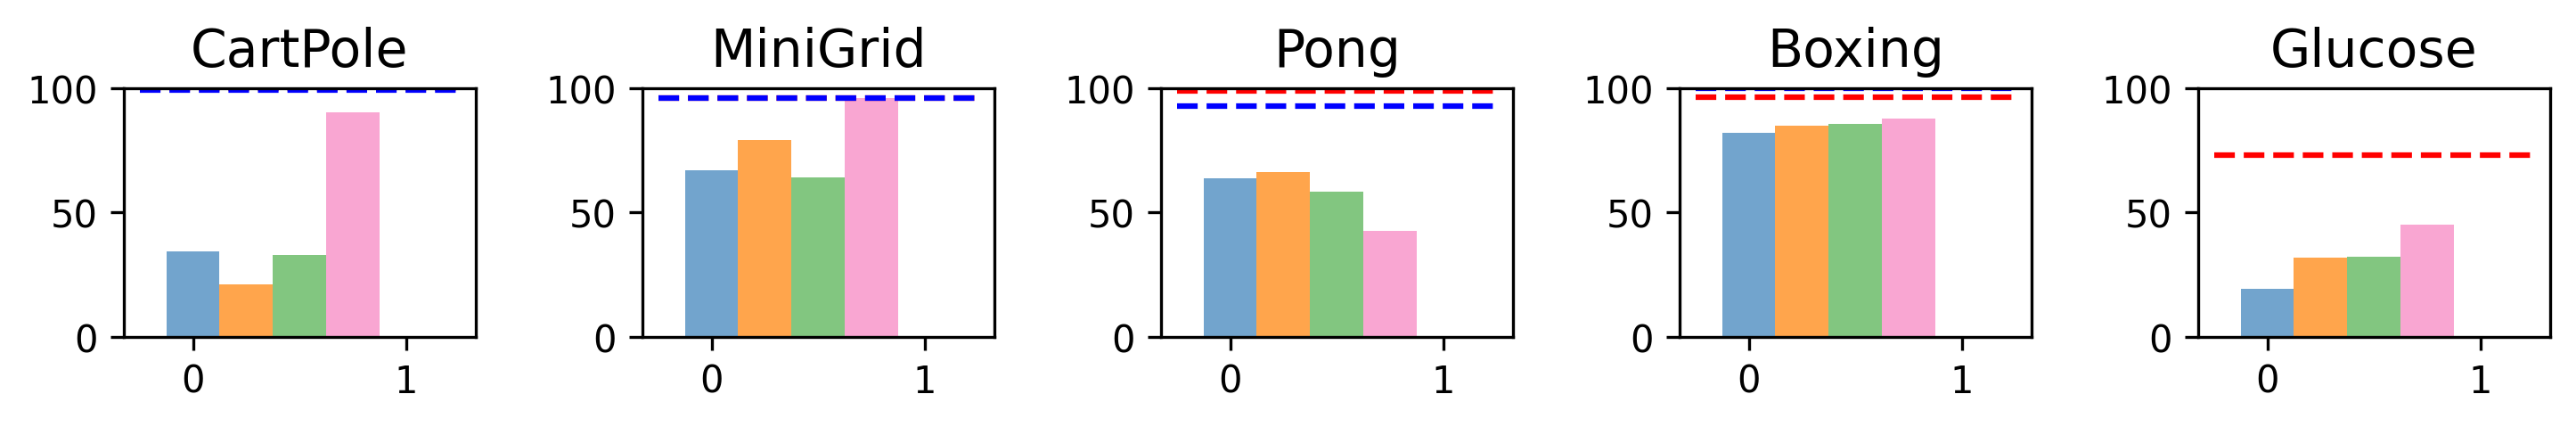

In [12]:
plot_dimensions = (1,len(perfect_environments))

titles = [[name_to_nice[i] for i in perfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(5)]]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(perfect_environments)):
    x_groups = list(range(len(all_performances_perfect[i][:-1])))
    y_vals = all_performances_perfect[i][1:]


    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], methods_dict,bar_format)
    
    ax[0][i].hlines(all_performances_perfect[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    
    if i!=len(perfect_environments)-1:
        ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

# legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 6, 'bbox_to_anchor': (0.1,-0.1),'fontsize': 14}
# create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_perfect.pdf",dpi=300, bbox_inches='tight')

4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1


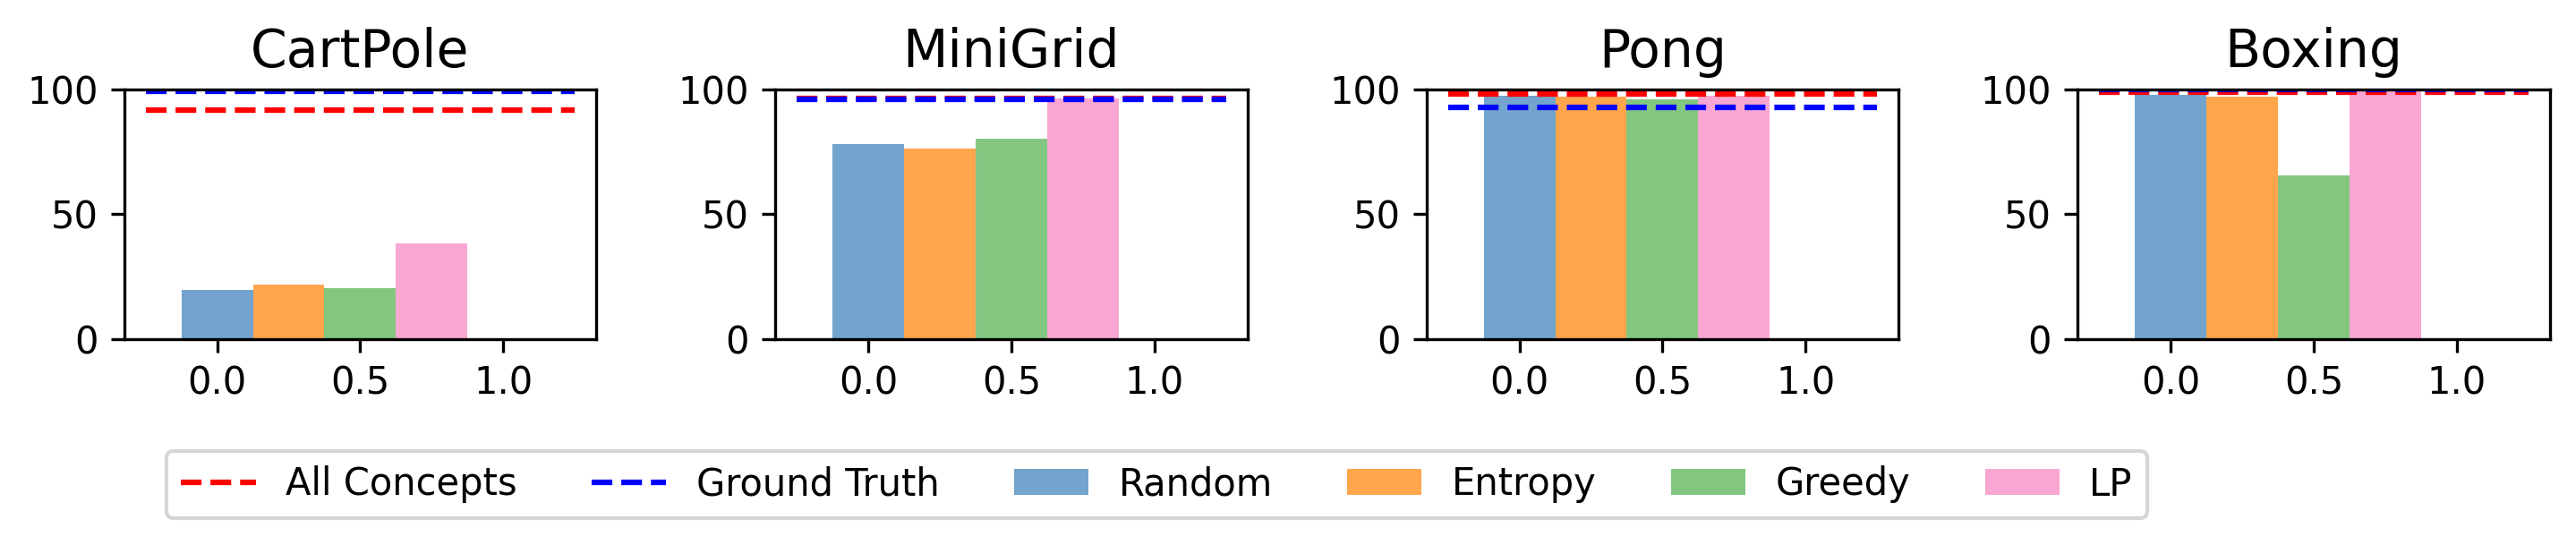

In [13]:
plot_dimensions = (1,len(imperfect_environments))

titles = [[name_to_nice[i] for i in imperfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(4)]],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(imperfect_environments)):
    x_groups = list(range(len(all_performances_imperfect[i][:-1])))
    y_vals = all_performances_imperfect[i][1:]

    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], methods_dict,bar_format)
    
    ax[0][i].hlines(all_performances_imperfect[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 7, 'bbox_to_anchor': (0.075,-0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_imperfect.pdf",dpi=300, bbox_inches='tight')

In [104]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["random","entropy","greedy","lp_hybrid"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_k = []
for j,e in enumerate(perfect_environments):
    temp_env = []
    for m in perfect_methods:
        temp = []

        for fraction_selected in [0.8,1,1.2,1.6]:
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                        'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                        'method': m, 'gold_timesteps': gold_timesteps[e]})


            if len(matching_params) == 0:
                matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                            'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                            'method': m, 'gold_timesteps': gold_timesteps[e], 'experiment': 'perfect_comparison'})

            performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
            print("Perfect",e,m,round(num_concepts_selected[e]*fraction_selected),[i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])],np.mean( [len(matching_params[i][m]['concepts']) for i in range(len(matching_params))]))

            if np.isnan(performance):
                performance = 0
            temp.append(performance)
        temp_env.append(temp)
    all_performances_k.append(temp_env)


Perfect cart_pole random 2 [119.64819277108434, 151.29051987767585, 184.57089552238807] 2.0
Perfect cart_pole random 3 [170.72916666666666, 306.8050314465409, 448.6542056074766] 3.0
Perfect cart_pole random 4 [280.04046242774564, 463.5192307692308, 169.43642611683848] 4.0
Perfect cart_pole random 5 [321.63758389261744, 296.6829268292683, 279.28323699421964] 5.0
Perfect cart_pole entropy 2 [120.43658536585366, 122.52605459057072, 44.43098842386465] 2.0
Perfect cart_pole entropy 3 [122.9801488833747, 292.45454545454544, 117.80952380952381] 3.0
Perfect cart_pole entropy 4 [358.4592592592593, 239.89268292682928, 268.74725274725273] 4.0
Perfect cart_pole entropy 5 [265.8415300546448, 279.21022727272725, 329.33561643835617] 5.0
Perfect cart_pole greedy 2 [118.6144578313253, 459.2019230769231, 112.67963386727689] 2.0
Perfect cart_pole greedy 3 [124.39393939393939, 100.18052738336714, 40.320647773279354] 3.0
Perfect cart_pole greedy 4 [250.36923076923077, 297.680981595092, 290.91616766467064] 

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Perfect pong lp_hybrid 57 [15.0, 15.142857142857142] 57.0
Perfect pong lp_hybrid 68 [15.5, 14.666666666666666, -13.0] 68.0
Perfect pong lp_hybrid 91 [] nan
Perfect boxing random 38 [73.16666666666667, 90.85714285714286, 72.86842105263158] 38.0
Perfect boxing random 48 [78.12820512820512, 68.44827586206897, 90.68852459016394] 48.0
Perfect boxing random 58 [84.5, 91.22388059701493, 75.20588235294117] 58.0
Perfect boxing random 77 [75.83783783783784, 65.5, 88.27586206896552] 77.0
Perfect boxing entropy 38 [81.7948717948718, 83.1304347826087, 77.725] 38.0
Perfect boxing entropy 48 [78.07692307692308, 77.45, 87.06976744186046] 48.0
Perfect boxing entropy 58 [87.61111111111111, 75.35714285714286, 74.75] 58.0
Perfect boxing entropy 77 [86.04166666666667, 88.27777777777777, 93.82352941176471] 77.0
Perfect boxing greedy 38 [93.09859154929578, 77.11904761904762, 77.65714285714286] 38.0
Perfect boxing greedy 48 [81.70833333333333, 78.07894736842105, 84.6938775510204] 48.0
Perfect boxing greedy 58

[[0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3]] [[30.367307211409884, 61.74589358137895, 60.86640795425433, 59.84024984774036], [19.1595752253526, 35.549614543162924, 57.80661299555609, 58.29249158438189], [46.033067651701685, 17.65967430337239, 55.93109200193289, 70.59975858515763], [38.39220847637533, 77.58903205640617, 84.17003035397856, 66.83171699195394]]
[[0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3]] [[40.95878811625672, 55.73281754739984, 60.18274020710893, 69.69796650142676], [36.58223383034935, 63.06619764094927, 82.10149430295401, 94.70055516259652], [49.485300419823304, 59.57521126992674, 70.98287367055302, 86.61844590756814], [85.58565421796209, 95.46228264471421, 93.78571897704346, 95.62710210499453]]
[[0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3]] [[30.458553791887127, 82.10978835978837, 79.67687074829932, 0], [17.261904761904763, 84.76190476190476, 92.8373015873016, 91.36904761904762], [16.666666666666664, 69.04761904761905, 95.53571428571429,

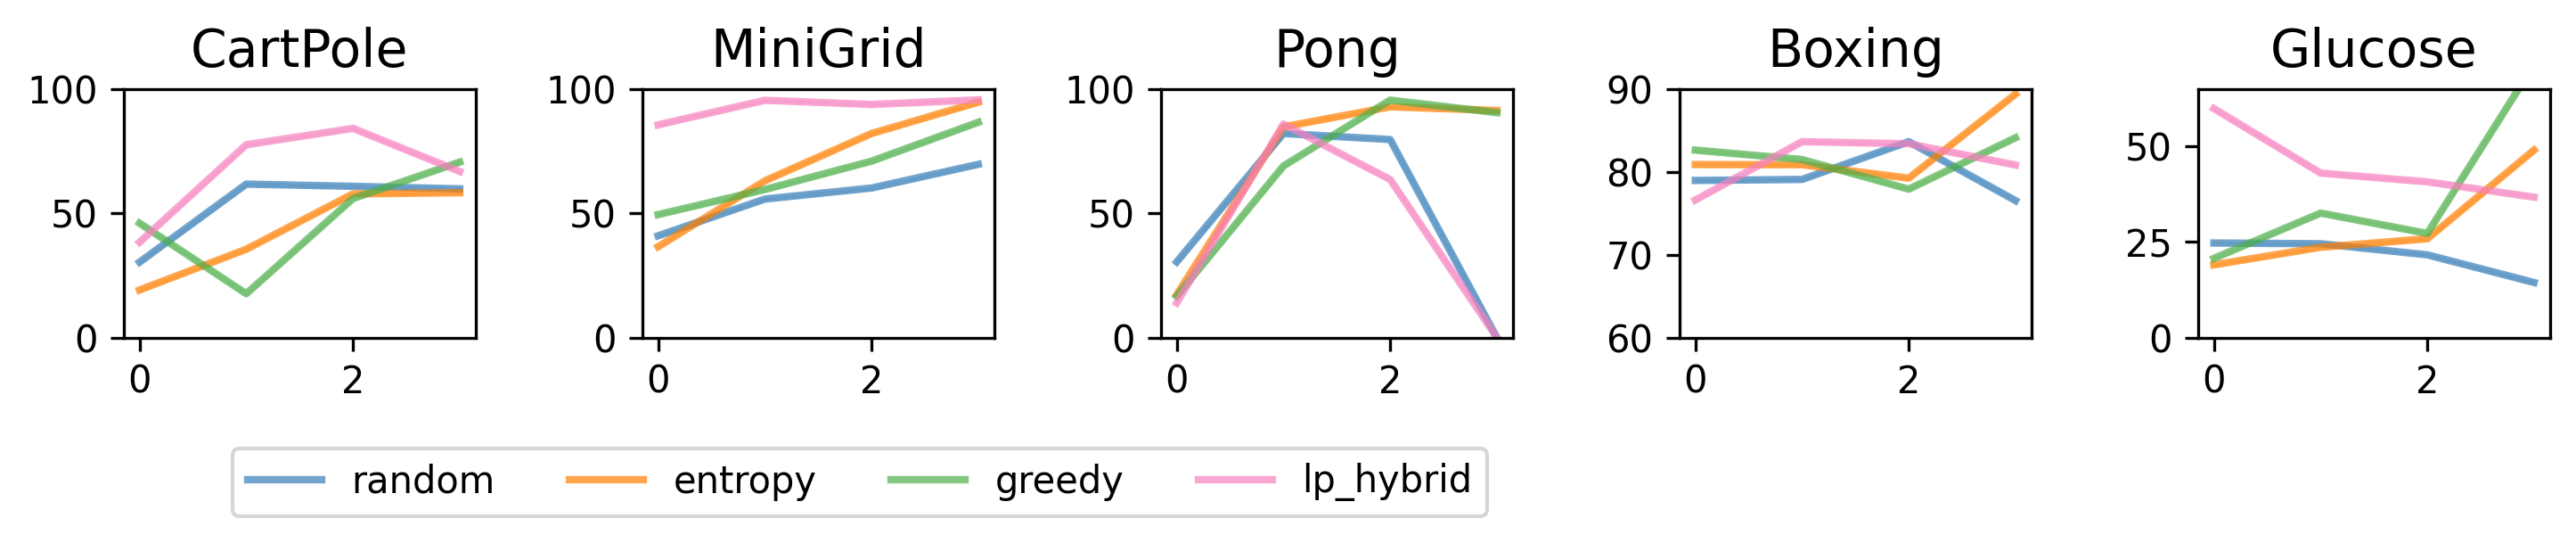

In [99]:
plot_dimensions = (1,len(perfect_environments))

titles = [[name_to_nice[i] for i in perfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100],[0,100],[0,100],[60,90],[0,65]]]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

for i in range(len(perfect_environments)):
    y_vals = all_performances_k[i]

    x_groups = [list(range(len(j))) for j in y_vals]

    print(x_groups,y_vals)

    plot_line(ax[0][i],x_groups,y_vals,np.zeros(np.array(y_vals).shape), perfect_methods,line_format)
    
legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 6, 'bbox_to_anchor': (0.1,-0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_perfect.pdf",dpi=300, bbox_inches='tight')

In [50]:
num_concepts_selected = [[1,2,3],[3,6,11],[57//4,57//2,57],[12,24,48],[2,5,10]]
accuracies = [0.75,0.85,0.95]
max_perf = [i+0.001 for i in all_baselines]
max_perf[3] = 100
max_perf[2] = 21
heatmap_by_env = [[[0 for k in range(len(num_concepts_selected[i]))] for j in accuracies] for i in range(len(perfect_environments))]

for i,e in enumerate(perfect_environments):
    for j,acc in enumerate(accuracies):
        for k,n in enumerate(num_concepts_selected[i]):
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e, 'concept_accuracy': acc,
                        'num_concepts_selected': n, 'training_timesteps': training_times[e]})
            print(e,acc,n,len(matching_params),[m['multiple']['reward'] for m in matching_params],round(np.mean([m['multiple']['reward'] for m in matching_params])/max_perf[i],2)*100)
            if len(matching_params) > 0 and 'multiple' in matching_params[0]:
                heatmap_by_env[i][j][k] = round(method_scales[i](np.mean([m['multiple']['reward'] for m in matching_params])))

cart_pole 0.75 1 3 [41.38704318936877, 38.26825518831668, 45.68135904499541] 42.0
cart_pole 0.75 2 3 [41.06286186931348, 47.113421550094515, 51.714880332986475] 47.0
cart_pole 0.75 3 3 [51.22966014418126, 95.72093023255815, 47.97019230769231] 65.0
cart_pole 0.85 1 3 [43.05613126079447, 43.91879964695499, 54.2308533916849] 47.0
cart_pole 0.85 2 3 [75.94036697247707, 45.40582347588717, 50.81122448979592] 57.99999999999999
cart_pole 0.85 3 3 [55.67673378076063, 200.70781893004116, 73.02058823529411] 110.00000000000001
cart_pole 0.95 1 3 [43.687445127304656, 43.90669014084507, 61.17589175891759] 50.0
cart_pole 0.95 2 3 [60.55596107055961, 124.36934673366834, 47.04824976348155] 78.0
cart_pole 0.95 3 3 [58.996437054631826, 142.70058139534885, 361.23703703703706] 188.0
mini_grid 0.75 3 3 [0.34474487615874294, 0.27174559475361615, 0.3069807401133908] 0.0
mini_grid 0.75 6 3 [0.338770422638512, 0.31388695721609006, 0.3521259522458674] 0.0
mini_grid 0.75 11 3 [0.33045428664024384, 0.3890993478981

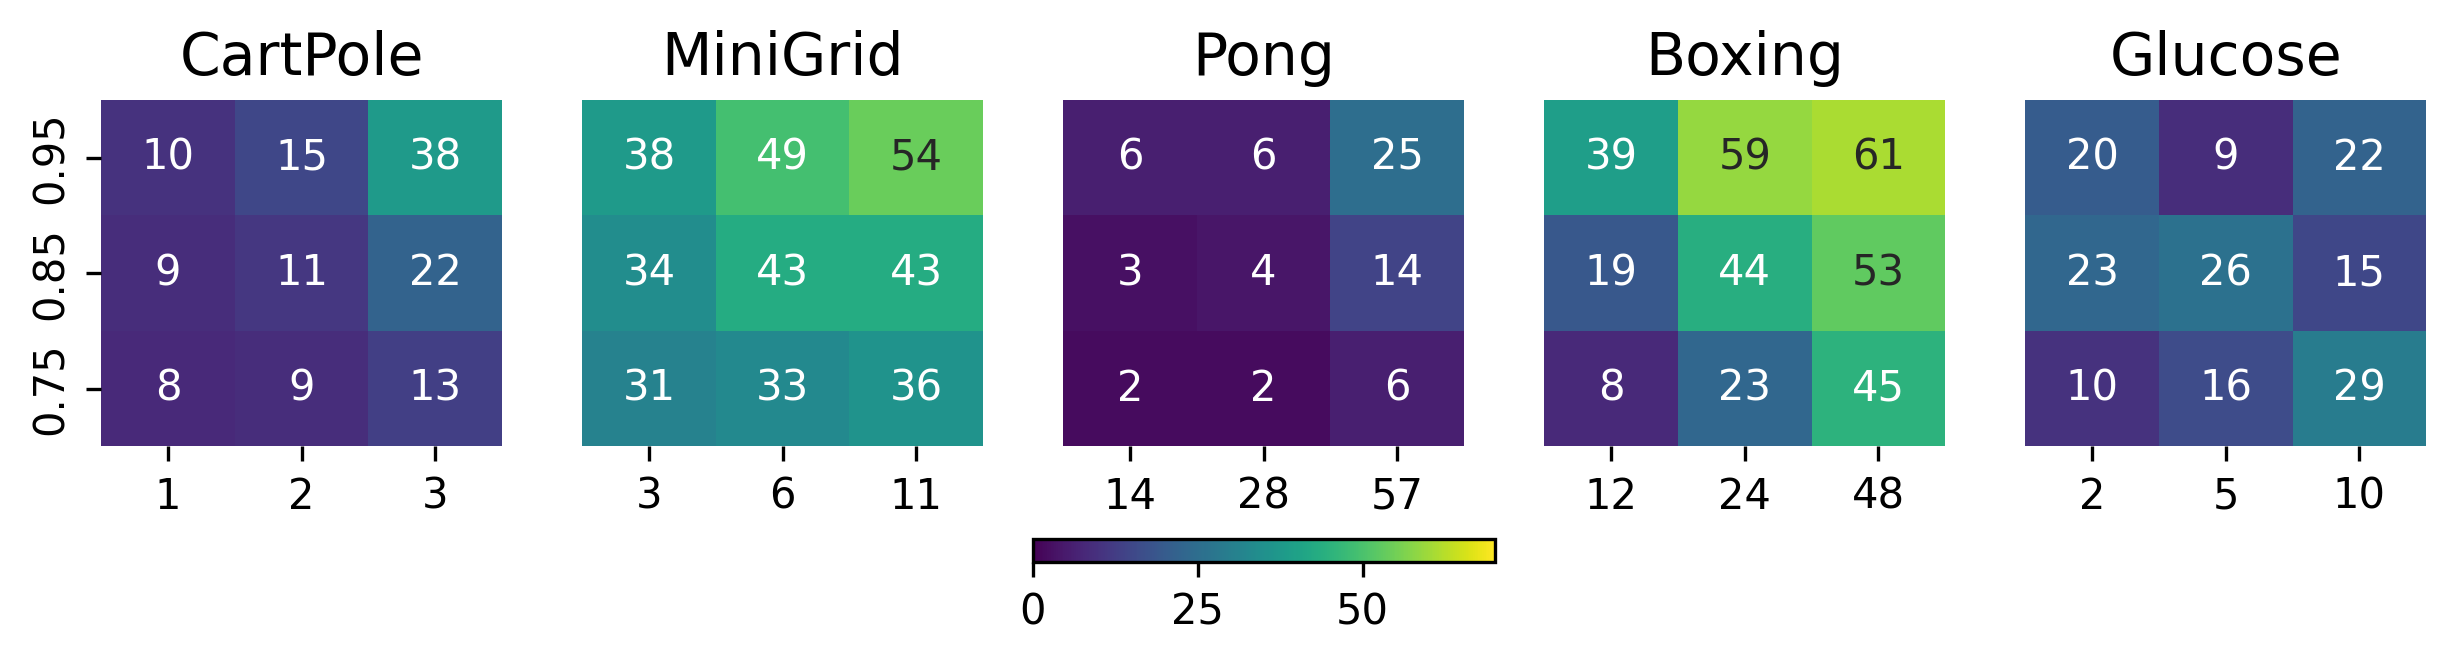

In [51]:
plot_dimensions = (1,len(perfect_environments))
def index_to_tuple(i):
    return (0,i)

def flatten_to_square(lst):
    res = [[0 for i in range(len(perfect_environments))] for j in range(1)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = [[name_to_nice[i] for i in perfect_environments]]
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

import matplotlib as mpl

fig, ax = create_axes(plot_dimensions, overall_format, titles=titles)

# Draw all heatmaps WITHOUT colorbars
for i in range(len(perfect_environments)):
    annot = accuracies 
    if i!=0:
        annot = [] 
    sns.heatmap(
        heatmap_by_env[i],
        ax=ax[0][i],
        cmap="viridis",
        xticklabels=num_concepts_selected[i],
        yticklabels=annot,
        vmin=0, vmax=70,   # ensure consistent scaling
        cbar=False,
        annot=True
    )
    ax[0][i].invert_yaxis()

# ---- GLOBAL HORIZONTAL COLORBAR (0 to 1) ----
norm = mpl.colors.Normalize(vmin=0, vmax=70)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis")
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=[a for row in ax for a in row],
    orientation='horizontal',
    fraction=0.05,    # thinner bar
    pad=0.20          # spacing from subplots
)

fig.savefig(
    "../../results/figures/num_concepts_accuracy.pdf",
    dpi=300,
    bbox_inches='tight')


In [52]:
num_concepts_selected = 11
concept_accuracies = [0.75,0.85,0.95]
environment = "mini_grid"
rewards = []

for acc in concept_accuracies:
    temp = []
    for t in [250000,500000,750000,1000000]:
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': environment,'num_concepts_selected': num_concepts_selected, 'concept_accuracy':acc, 'training_timesteps': t})
        print(acc,t,len(matching_params))
        temp.append(method_scales[1](np.mean([i['multiple']['reward'] for i in matching_params])))
    rewards.append(temp)
rewards_accuracy = np.array(rewards)

0.75 250000 3
0.75 500000 3
0.75 750000 3
0.75 1000000 3
0.85 250000 3
0.85 500000 3
0.85 750000 3
0.85 1000000 3
0.95 250000 3
0.95 500000 3
0.95 750000 3
0.95 1000000 3


In [53]:
acc = 0.9
num_concepts_selected = [3,6,11]
environment = "mini_grid"
total_concepts = 44
rewards = []

for n in num_concepts_selected:
    temp = []
    for t in [250000,500000,750000,1000000]:
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': environment,'num_concepts_selected': n, 'concept_accuracy':0.95, 'training_timesteps': t})
        print(n,t,len(matching_params))
        temp.append(method_scales[1](np.mean([i['multiple']['reward'] for i in matching_params])))
    rewards.append(temp)
rewards_num_concepts = np.array(rewards)
rewards_num_concepts

3 250000 3
3 500000 3
3 750000 3
3 1000000 3
6 250000 3
6 500000 3
6 750000 3
6 1000000 3
11 250000 3
11 500000 3
11 750000 3
11 1000000 3


array([[22.71557953, 38.1955301 , 39.514523  , 38.40815411],
       [32.1309221 , 48.63486737, 41.63637068, 42.73954345],
       [40.7307803 , 53.8473115 , 58.79269046, 64.10559454]])

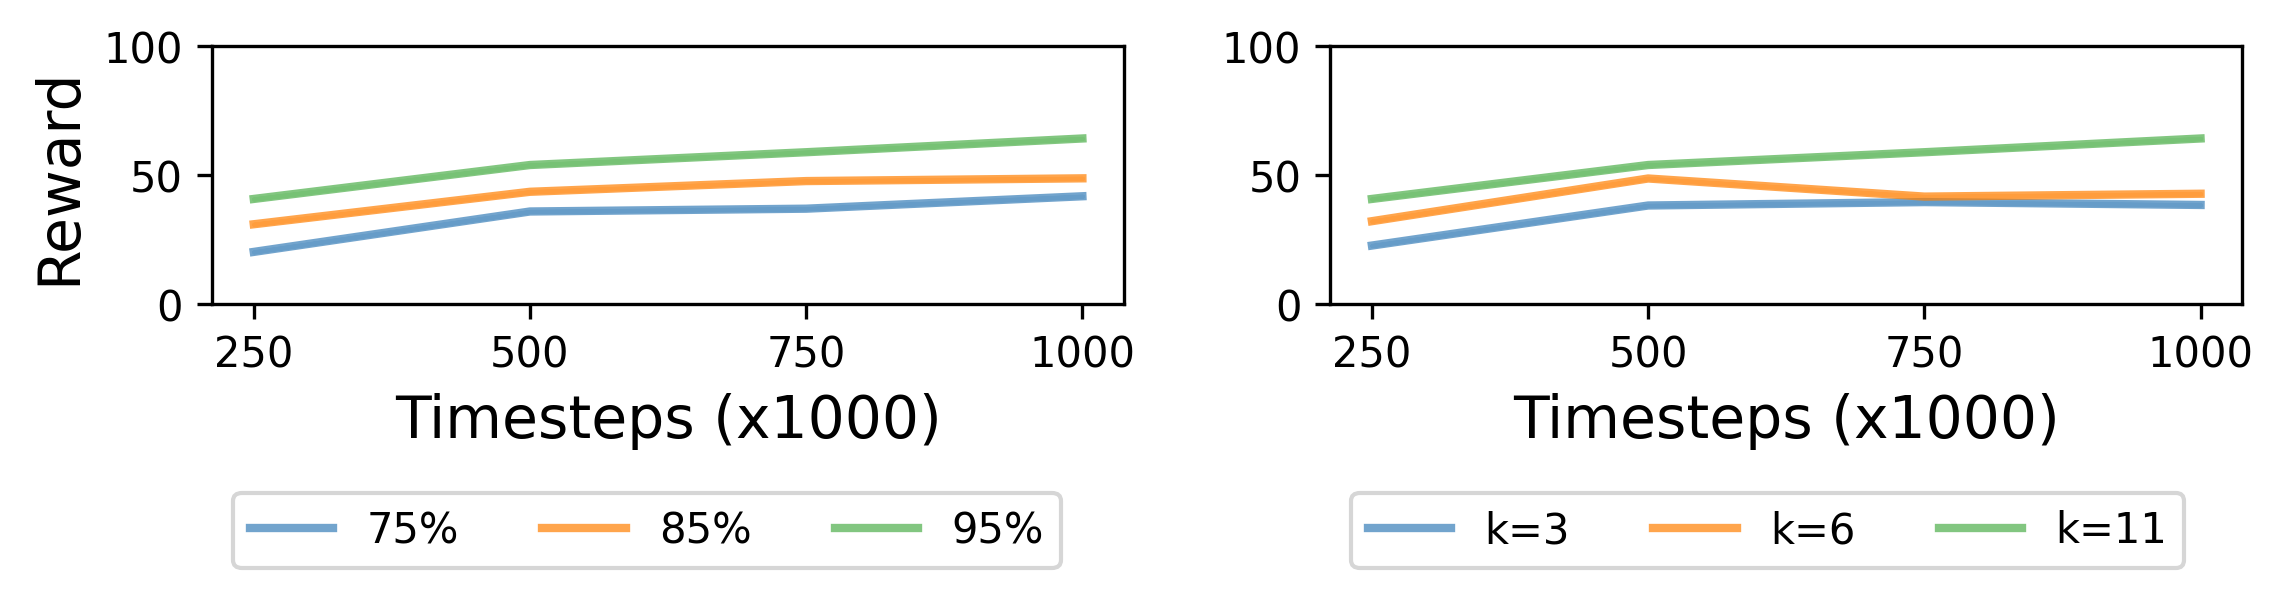

In [54]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,2)
def index_to_tuple(i):
    return (0,i)

def flatten_to_square(lst):
    res = [[0 for i in range(2)] for j in range(1)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res


sup_y_label = ""
overall_format = {'figsize':(8,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[[0,1,2,3],["250","500","750","1000"]] for i in range(2)]],
    'y_ticks': [[[[0,50,100],["0","50","100"]] for i in range(2)]],
    'y_lim': [[[0,100] for i in range(2)]],

}

fig,ax = create_axes(plot_dimensions,overall_format,y_labels=[["Reward",""]],x_labels=[["Timesteps (x1000)","Timesteps (x1000)"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(4)) for i in range(3)]
y_vals = rewards_accuracy
y_std = [[0 for i in range(4)] for i in range(3)]
plot_line(ax[0][0],x_groups,y_vals,y_std,["{}%".format(round(i*100)) for i in concept_accuracies],line_format)

x_groups = [list(range(4)) for i in range(3)]
y_vals = rewards_num_concepts 
y_std = [[0 for i in range(4)] for i in range(3)]
plot_line(ax[0][1],x_groups,y_vals,y_std,["k={}".format(i) for i in num_concepts_selected],line_format)


legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (0,-1.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/accuracy_num_concepts.pdf",dpi=300, bbox_inches='tight')

In [74]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing"]

intervention_probability = [0.25,0.5,0.75]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

cart_pole_interventions = []
e = "cart_pole"
cart_pole_interventions.append(all_performances_imperfect[0][1:])
for i in intervention_probability:
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],
                                                                    'method': m, 'intervention_prob': i})
        if len(matching_params) > 0:
            performance = method_scales[0](np.mean([i[m]['reward'] for i in matching_params]))
            temp.append(performance)
        else:
            temp.append(0.0001)
    cart_pole_interventions.append(temp)
intervention_probability.append(1.0)
intervention_probability = [0.0] + intervention_probability
cart_pole_interventions.append(all_performances_perfect[0][1:])

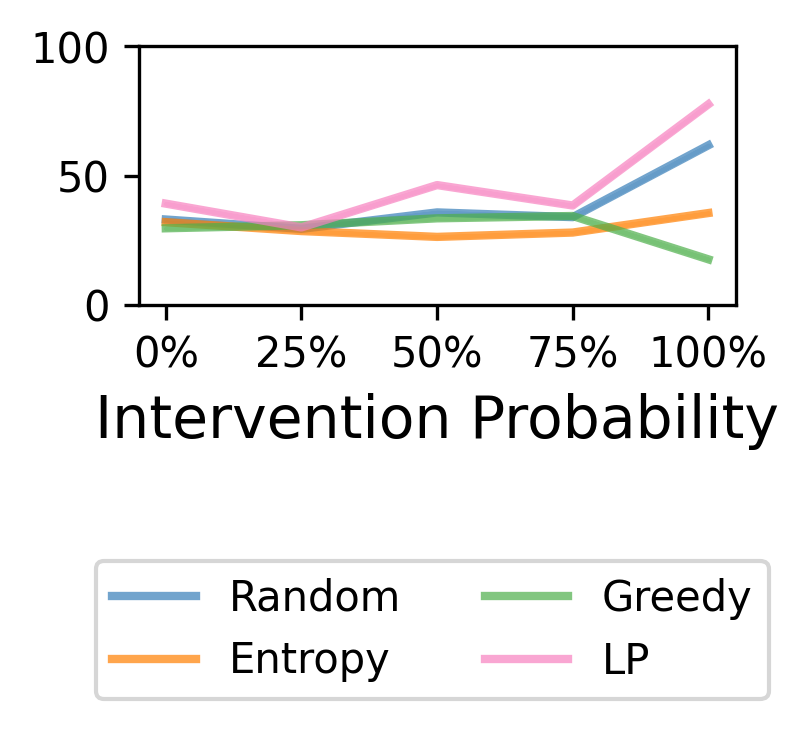

In [75]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)
titles = [[""]]

sup_y_label = ""
overall_format = {'figsize':(3,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(intervention_probability))),["0%","25%","50%","75%","100%"]] for i in range(5)] for j in range(1)],
    'y_lim': [[[0,100]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,x_labels=[["Intervention Probability"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(len(intervention_probability))) for j in imperfect_methods]
y_vals = np.array(cart_pole_interventions).T
y_std = np.zeros(y_vals.shape)
plot_line(ax[0][0],x_groups,y_vals,y_std,['Random','Entropy','Greedy','LP'],line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 2, 'bbox_to_anchor': (0.15,-0.3),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/intervention_comparison.pdf",dpi=300, bbox_inches='tight')


In [ ]:
e = 'cart_pole'
matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],
                                                                    'method': 'multiple', 'intervention_prob': 0.5})
accuracies = np.array(matching_params[0]['concept_accuracy'])
intervention_probability = [0.25,0.5,0.75]

selected_concepts = []
for m in imperfect_methods:
    matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                'num_concepts_selected': num_concepts_selected[e],
                                                                'method': m, 'intervention_prob': 0.5})
    selected_concepts.append(matching_params[0][m]['concepts'])

baseline_accuracies = [accuracies[i] for i in selected_concepts]
intervention_accuracies = []
for i in intervention_probability:
    intervention_accuracies.append([(i)*np.ones(3) + (1-i)*j for j in baseline_accuracies])
intervention_accuracies = np.array(intervention_accuracies)
intervention_accuracies = np.mean(intervention_accuracies,axis=2)
baseline_accuracies = [np.mean(i) for i in baseline_accuracies]

cart_pole_intervention_performance = cart_pole_interventions[2]
cart_pole_baseline_performance = cart_pole_interventions[0]
baseline_combo = np.array(list(zip(baseline_accuracies,cart_pole_baseline_performance)))
intervention_combo = np.array(list(zip(intervention_accuracies[1],cart_pole_intervention_performance)))

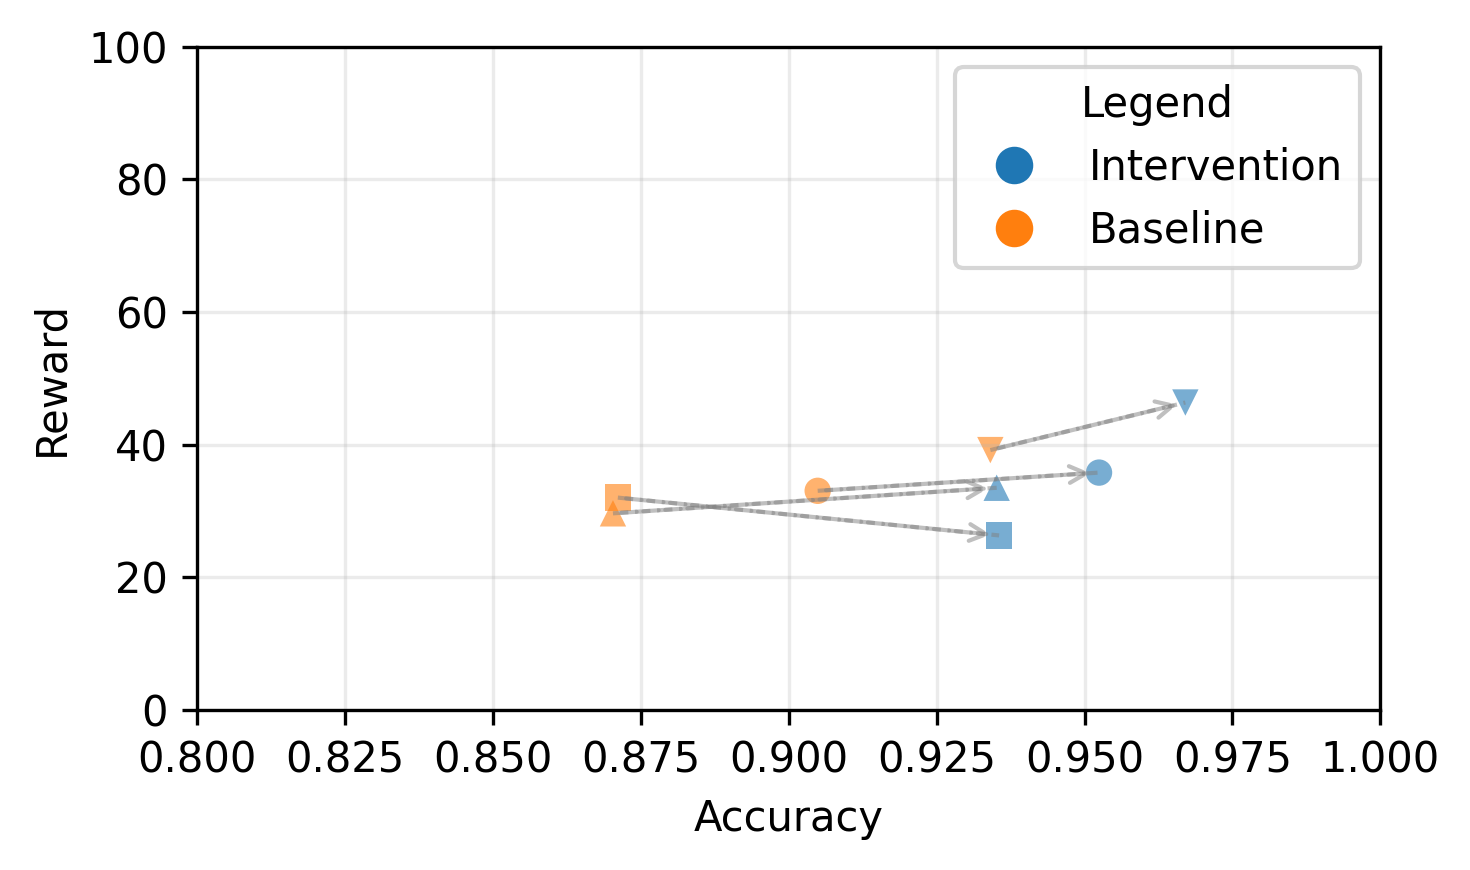

In [ ]:
import matplotlib.lines as mlines

plt.figure(figsize=(5,3))

plt.xlim([0.8,1])
# ----------------------------------------------------
# Scatter plots (soft)
# ----------------------------------------------------
markers = ['o', 's', '^', 'v', 'D', 'P', 'X', '*', '<', '>']  # extend if needed

for i, (x, y) in enumerate(intervention_combo):
    plt.scatter(
        x, y,
        marker=markers[i % len(markers)],
        s=40, alpha=0.6, edgecolors='none',
        label='Intervention' if i == 0 else None,
        color='C0'
    )

# Plot baseline with unique markers
for i, (x, y) in enumerate(baseline_combo):
    plt.scatter(
        x, y,
        marker=markers[i % len(markers)],
        s=40, alpha=0.6, edgecolors='none',
        label='Baseline' if i == 0 else None,
        color='C1'
    )

# ----------------------------------------------------
# Pareto front (maximize x, minimize y)
# ----------------------------------------------------
def pareto_front(points):
    # Sort by x descending (maximize x)
    pts = points[points[:,0].argsort()[::-1]]
    front = [pts[0]]
    for p in pts[1:]:
        if p[1] >= front[-1][1]:  # minimize y
            front.append(p)
    return np.array(front)

intervention_pf = pareto_front(intervention_combo)
baseline_pf     = pareto_front(baseline_combo)

plt.plot(intervention_pf[:,0], intervention_pf[:,1],
         linewidth=2, label='Intervention Pareto')
plt.plot(baseline_pf[:,0], baseline_pf[:,1],
         linewidth=2, label='Baseline Pareto')

# ----------------------------------------------------
# Extend fronts to axes
# ----------------------------------------------------
def extend_to_axes(front, color, y_max=None):
    ax = plt.gca()

    # get max y after all plotting is done if not provided
    if y_max is None:
        y_min, y_max = ax.get_ylim()

    # First PF point = largest x
    x0, y0 = front[0]
    # vertical line up to y_max
    plt.plot([x0, x0], [y_min,y0], linestyle='--', linewidth=1, color=color)

    # Last PF point = smallest y
    x1, y1 = front[-1]
    # horizontal line to x=0
    plt.plot([0, x1], [y1, y1], linestyle='--', linewidth=1, color=color)

# Add axis extension lines

# ----------------------------------------------------
# Flip y-axis (because lower is better)
# ----------------------------------------------------

# ----------------------------------------------------
# Labels and style
# ----------------------------------------------------
plt.xlabel("Accuracy")
plt.ylabel("Reward")
plt.ylim([0,100])
for (x_b, y_b), (x_i, y_i) in zip(baseline_combo, intervention_combo):
    plt.plot(
        [x_b, x_i],
        [y_b, y_i],
        linestyle='--',
        linewidth=1,
        alpha=0.5,
        color='gray',
        zorder=1
    )
for (x_b, y_b), (x_i, y_i) in zip(baseline_combo, intervention_combo):
    plt.annotate(
        "",
        xy=(x_i, y_i),
        xytext=(x_b, y_b),
        arrowprops=dict(
            arrowstyle="->",
            linestyle="--",
            color="gray",
            alpha=0.5,
            linewidth=1
        )
    )


unique_n = len(intervention_combo)               # e.g., 4
unique_markers = markers[:unique_n]             # use the first N markers
marker_labels = imperfect_methods

marker_handles = [
    mlines.Line2D(
        [], [], 
        color='black',                 # neutral color for legend
        marker=unique_markers[i],
        linestyle='None',
        markersize=8,
        label=marker_labels[i]
    )
    for i in range(unique_n)
]

# After your existing plt.legend():

# Add the marker-only legend
intervention_handle = mlines.Line2D(
    [], [], color='C0', marker='o', linestyle='None',
    markersize=8, label='Intervention'
)

baseline_handle = mlines.Line2D(
    [], [], color='C1', marker='o', linestyle='None',
    markersize=8, label='Baseline'
)

# ----------------------------------------------------
# Marker entries (same color, different markers)
# ----------------------------------------------------
unique_n = len(intervention_combo)
unique_markers = markers[:unique_n]


# ----------------------------------------------------
# Combine everything into one legend
# ----------------------------------------------------
all_handles = [intervention_handle, baseline_handle]

plt.legend(handles=all_handles, title="Legend", loc="best")

plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig("../../results/figures/pareto_reward.pdf",dpi=300, bbox_inches='tight')



In [67]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing"]

intervention_probability = [0.25,0.5,0.75]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

cart_pole_interventions = []
e = "boxing"
cart_pole_interventions.append(all_performances_imperfect[3][1:])
for i in intervention_probability:
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],
                                                                    'method': m, 'intervention_prob': i})
        if len(matching_params) > 0:
            performance = method_scales[3](np.mean([i[m]['reward'] for i in matching_params]))
            temp.append(performance)
        else:
            temp.append(0.0001)
    cart_pole_interventions.append(temp)
intervention_probability.append(1.0)
intervention_probability = [0.0] + intervention_probability
cart_pole_interventions.append(all_performances_perfect[0][1:])

e = 'cart_pole'
matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],
                                                                    'method': 'multiple', 'intervention_prob': 0.5})
accuracies = np.array(matching_params[0]['concept_accuracy'])
intervention_probability = [0.25,0.5,0.75]

selected_concepts = []
for m in imperfect_methods:
    matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                'num_concepts_selected': num_concepts_selected[e],
                                                                'method': m, 'intervention_prob': 0.5})
    selected_concepts.append(matching_params[0][m]['concepts'])

baseline_accuracies = [accuracies[i] for i in selected_concepts]
intervention_accuracies = []
for i in intervention_probability:
    intervention_accuracies.append([(i)*np.ones(3) + (1-i)*j for j in baseline_accuracies])
intervention_accuracies = np.array(intervention_accuracies)
intervention_accuracies = np.mean(intervention_accuracies,axis=2)
baseline_accuracies = [np.mean(i) for i in baseline_accuracies]

cart_pole_intervention_performance = cart_pole_interventions[2]
cart_pole_baseline_performance = cart_pole_interventions[0]
baseline_combo = np.array(list(zip(baseline_accuracies,cart_pole_baseline_performance)))
intervention_combo = np.array(list(zip(intervention_accuracies[1],cart_pole_intervention_performance)))

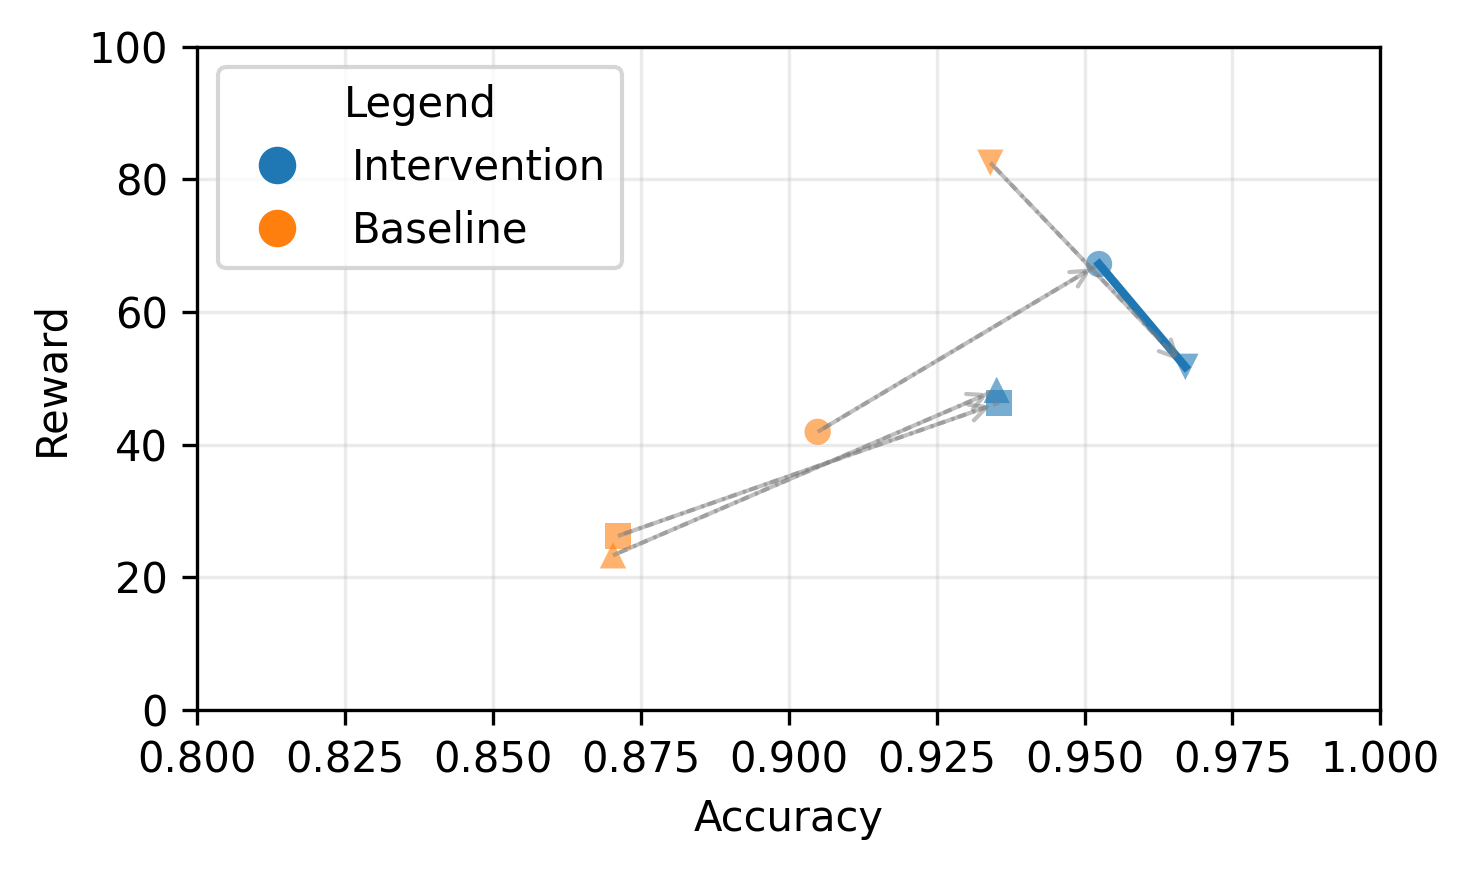

In [68]:
import matplotlib.lines as mlines

plt.figure(figsize=(5,3))

plt.xlim([0.8,1])
# ----------------------------------------------------
# Scatter plots (soft)
# ----------------------------------------------------
markers = ['o', 's', '^', 'v', 'D', 'P', 'X', '*', '<', '>']  # extend if needed

for i, (x, y) in enumerate(intervention_combo):
    plt.scatter(
        x, y,
        marker=markers[i % len(markers)],
        s=40, alpha=0.6, edgecolors='none',
        label='Intervention' if i == 0 else None,
        color='C0'
    )

# Plot baseline with unique markers
for i, (x, y) in enumerate(baseline_combo):
    plt.scatter(
        x, y,
        marker=markers[i % len(markers)],
        s=40, alpha=0.6, edgecolors='none',
        label='Baseline' if i == 0 else None,
        color='C1'
    )

# ----------------------------------------------------
# Pareto front (maximize x, minimize y)
# ----------------------------------------------------
def pareto_front(points):
    # Sort by x descending (maximize x)
    pts = points[points[:,0].argsort()[::-1]]
    front = [pts[0]]
    for p in pts[1:]:
        if p[1] >= front[-1][1]:  # minimize y
            front.append(p)
    return np.array(front)

intervention_pf = pareto_front(intervention_combo)
baseline_pf     = pareto_front(baseline_combo)

plt.plot(intervention_pf[:,0], intervention_pf[:,1],
         linewidth=2, label='Intervention Pareto')
plt.plot(baseline_pf[:,0], baseline_pf[:,1],
         linewidth=2, label='Baseline Pareto')

# ----------------------------------------------------
# Extend fronts to axes
# ----------------------------------------------------
def extend_to_axes(front, color, y_max=None):
    ax = plt.gca()

    # get max y after all plotting is done if not provided
    if y_max is None:
        y_min, y_max = ax.get_ylim()

    # First PF point = largest x
    x0, y0 = front[0]
    # vertical line up to y_max
    plt.plot([x0, x0], [y_min,y0], linestyle='--', linewidth=1, color=color)

    # Last PF point = smallest y
    x1, y1 = front[-1]
    # horizontal line to x=0
    plt.plot([0, x1], [y1, y1], linestyle='--', linewidth=1, color=color)

# Add axis extension lines

# ----------------------------------------------------
# Flip y-axis (because lower is better)
# ----------------------------------------------------

# ----------------------------------------------------
# Labels and style
# ----------------------------------------------------
plt.xlabel("Accuracy")
plt.ylabel("Reward")
plt.ylim([0,100])
for (x_b, y_b), (x_i, y_i) in zip(baseline_combo, intervention_combo):
    plt.plot(
        [x_b, x_i],
        [y_b, y_i],
        linestyle='--',
        linewidth=1,
        alpha=0.5,
        color='gray',
        zorder=1
    )
for (x_b, y_b), (x_i, y_i) in zip(baseline_combo, intervention_combo):
    plt.annotate(
        "",
        xy=(x_i, y_i),
        xytext=(x_b, y_b),
        arrowprops=dict(
            arrowstyle="->",
            linestyle="--",
            color="gray",
            alpha=0.5,
            linewidth=1
        )
    )


unique_n = len(intervention_combo)               # e.g., 4
unique_markers = markers[:unique_n]             # use the first N markers
marker_labels = imperfect_methods

marker_handles = [
    mlines.Line2D(
        [], [], 
        color='black',                 # neutral color for legend
        marker=unique_markers[i],
        linestyle='None',
        markersize=8,
        label=marker_labels[i]
    )
    for i in range(unique_n)
]

# After your existing plt.legend():

# Add the marker-only legend
intervention_handle = mlines.Line2D(
    [], [], color='C0', marker='o', linestyle='None',
    markersize=8, label='Intervention'
)

baseline_handle = mlines.Line2D(
    [], [], color='C1', marker='o', linestyle='None',
    markersize=8, label='Baseline'
)

# ----------------------------------------------------
# Marker entries (same color, different markers)
# ----------------------------------------------------
unique_n = len(intervention_combo)
unique_markers = markers[:unique_n]


# ----------------------------------------------------
# Combine everything into one legend
# ----------------------------------------------------
all_handles = [intervention_handle, baseline_handle]

plt.legend(handles=all_handles, title="Legend", loc="best")

plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig("../../results/figures/pareto_reward.pdf",dpi=300, bbox_inches='tight')



In [25]:
gold_timesteps = [100000,250000,500000]
methods = ["greedy","lp_hybrid"]
e = "mini_grid"

performance_by_gold = []
for m in methods:
    temp = []
    for g in gold_timesteps:
        matching_params = get_results_matching_parameters("ablations","",{'environment_string': e,'gold_timesteps':g,
                                                                    'method': m})
        if len(matching_params) > 0:
            val = method_scales[1](np.mean([i[m]['reward'] for i in matching_params]))
        else:
            val = 0
        temp.append(val)
    performance_by_gold.append(temp)
np.array(performance_by_gold)

array([[48.44095232, 47.94062803, 60.05950556],
       [91.81564678, 93.26298131, 94.4886942 ]])

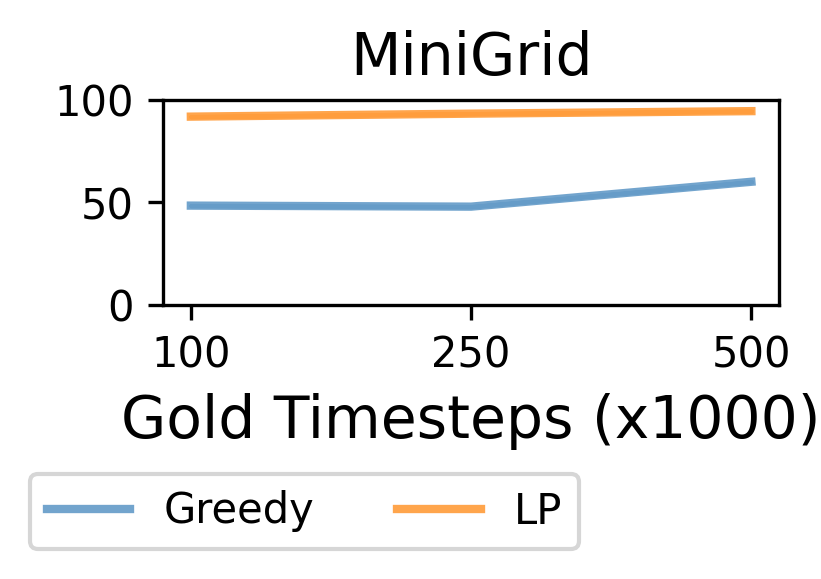

In [26]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)
titles = [["MiniGrid"]]

sup_y_label = ""
overall_format = {'figsize':(3,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(gold_timesteps))),[str(g//1000) for g in gold_timesteps]] for i in range(5)] for j in range(1)],
    'y_lim': [[[0,100]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,x_labels=[["Gold Timesteps (x1000)"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(3)) for j in range(2)]
y_vals = np.array(performance_by_gold)
y_std = np.zeros(y_vals.shape)
plot_line(ax[0][0],x_groups,y_vals,y_std,["Greedy","LP"],line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.05,-0.05),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/gold_timesteps.pdf",dpi=300, bbox_inches='tight')

In [80]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["perfect_concepts","lp_hybrid","policy_selection_lp","lp_old"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["imperfect_concepts","lp_hybrid","policy_selection_lp","lp_old"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_perfect_lp = []
all_performances_imperfect_lp = []

all_baselines = []

for j,e in enumerate(perfect_environments):
    temp = []
    for m in perfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'perfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        print("Perfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])

        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)
    all_performances_perfect_lp.append(temp)

for j,e in enumerate(imperfect_environments):
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        
        print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])
        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)

        if m == 'multiple':
            print("Environment",e,[i['concept_accuracy'] for i in matching_params])

    all_performances_imperfect_lp.append(temp)

for j,e in enumerate(imperfect_environments):
    matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],'gold_timesteps': gold_timesteps[e],
                                                                'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison'})
    matching_params = [i for i in matching_params if 'ground_truth' in i]
    performance = method_scales[j](np.mean([i['ground_truth']['reward'] for i in matching_params]))
    all_baselines.append(performance)
all_baselines.append(0)

Perfect cart_pole perfect_concepts 3 [(498.1666666666667, 43, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (500.0, 42, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (500.0, 44, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])]
Perfect cart_pole lp_hybrid 3 [(400.975, 44, [5, 6, 7]), (348.15107913669067, 42, [4, 6, 7]), (414.70940170940173, 43, [6, 7, 10])]
Perfect cart_pole policy_selection_lp 3 [(330.0816326530612, 44, [4, 6, 7]), (450.79245283018867, 43, [4, 6, 7]), (440.56363636363636, 42, [3, 6, 7])]
Perfect cart_pole lp_old 3 [(395.1951219512195, 43, [4, 7, 10]), (118.69064748201438, 44, [3, 4, 10]), (122.06896551724138, 42, [2, 4, 10])]
Perfect mini_grid perfect_concepts 3 [(0.9589964280213279, 42, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43]), (0.9598770935532239, 44, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29,

3 six_color 1
3 six_color 1
3 six_color 1
3 six_color 1
3 six_color 1


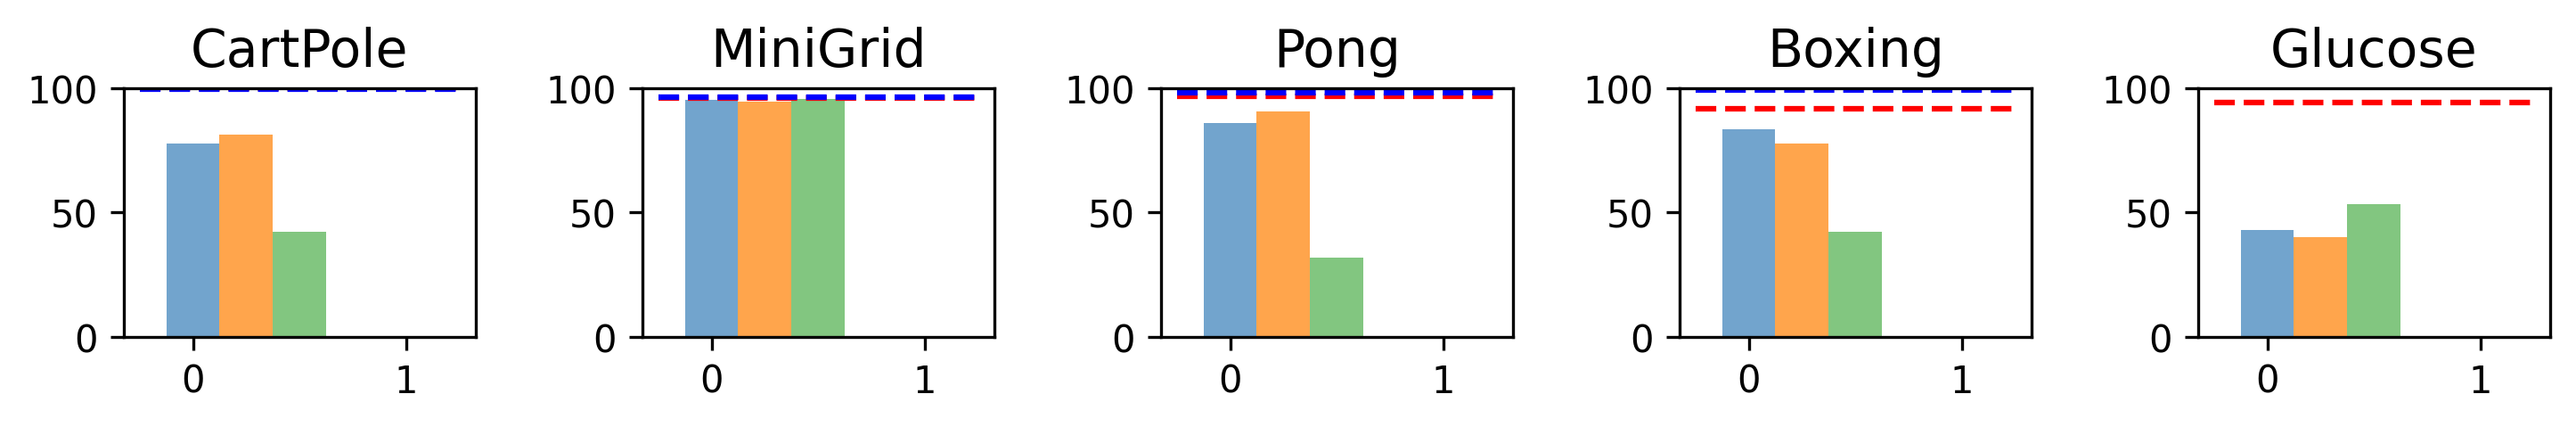

In [84]:
plot_dimensions = (1,len(perfect_environments))

titles = [[name_to_nice[i] for i in perfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(5)]]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(perfect_environments)):
    x_groups = list(range(len(all_performances_perfect_lp[i][:-1])))
    y_vals = all_performances_perfect_lp[i][1:]


    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], {
        0: 'LP',
        1: 'Policy-LP',
        2: 'Q-LP'
    },bar_format)
    
    ax[0][i].hlines(all_performances_perfect_lp[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    
    if i!=len(perfect_environments)-1:
        ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

# legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 6, 'bbox_to_anchor': (0.1,-0.1),'fontsize': 14}
# create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_perfect.pdf",dpi=300, bbox_inches='tight')

3 six_color 1
3 six_color 1
3 six_color 1
3 six_color 1


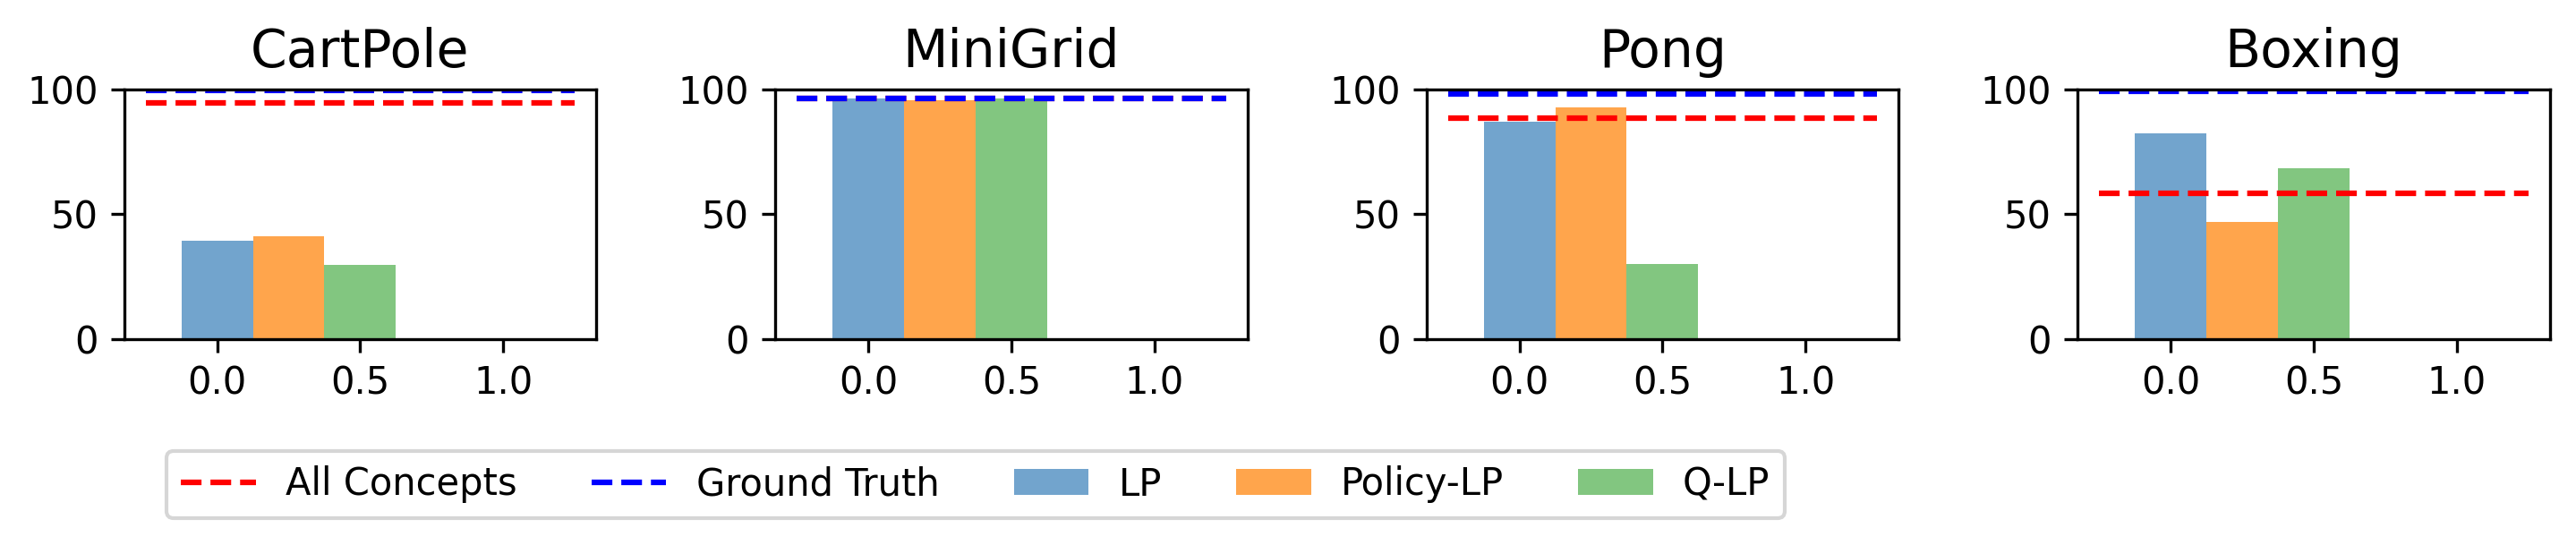

In [85]:
plot_dimensions = (1,len(imperfect_environments))

titles = [[name_to_nice[i] for i in imperfect_environments]]

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(4)]],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(imperfect_environments)):
    x_groups = list(range(len(all_performances_imperfect_lp[i][:-1])))
    y_vals = all_performances_imperfect_lp[i][1:]

    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))],  {
        0: 'LP',
        1: 'Policy-LP',
        2: 'Q-LP'
    },bar_format)
    
    ax[0][i].hlines(all_performances_imperfect_lp[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 7, 'bbox_to_anchor': (0.075,-0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_imperfect.pdf",dpi=300, bbox_inches='tight')

In [27]:
all_performances_imperfect_ablation = deepcopy(all_performances_imperfect)
for j,e in enumerate(["mini_grid"]):
    j = 1 
    temp = []    
    for m in ["completeness","lp_policy"]:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,
                                                                        'method': m})
        all_performances_imperfect_ablation[j].append(method_scales[j](np.mean([i[m]['reward'] for i in matching_params])))

6 eight_color 1


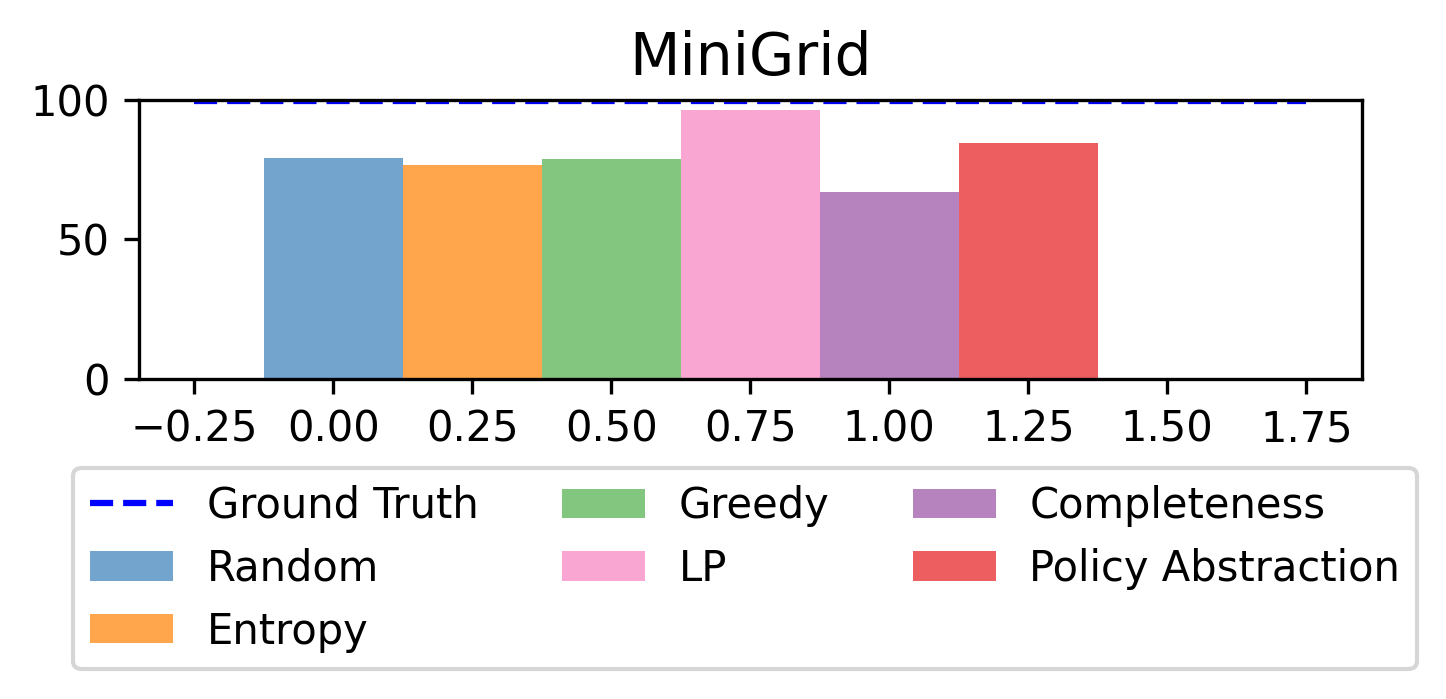

In [28]:
imperfect_environments = ["MiniGrid"]
plot_dimensions = (1,len(imperfect_environments))

titles = [imperfect_environments]

sup_y_label = ""
overall_format = {'figsize':(5,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100],[0,100],[0,21],[0,100]]],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'eight_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(imperfect_environments)):
    x_groups = list(range(len(all_performances_imperfect_ablation[1])))
    y_vals = all_performances_imperfect_ablation[1]
    
    d = {
        0: 'Random',
        1: 'Entropy',
        2: 'Greedy',
        3: 'LP',
        4: 'Completeness',
        5: 'Policy Abstraction'
    }

    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], d,bar_format)
    
    ax[0][i].hlines(all_baselines[i],-0.25,1.75,label="Ground Truth",color="blue",linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (0.075,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_imperfect_ablation.pdf",dpi=300, bbox_inches='tight')

In [29]:
matching_params = get_results_matching_parameters("cub","",{'num_concepts_selected': 311})
matching_params = [i for i in matching_params if 'epochs' not in i['parameters']]
perfect_lp = [[m['perfect']['lp'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
chosen_concepts = np.mean([m['perfect']['manual']['reward'] for m in matching_params])
similarity = [[len(set(matching_params[0]['perfect']['lp'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
perfect_lp = np.mean(perfect_lp,axis=0)
similarity = np.mean(similarity,axis=1)

In [30]:
imperfect_lp = [[m['imperfect']['lp'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
imperfect_lp = np.mean(imperfect_lp,axis=0)
multiple_lp = [[m['imperfect']['multiple'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
multiple_lp = np.mean(multiple_lp,axis=0)

greedy = [[m['imperfect']['greedy'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
greedy = np.mean(greedy,axis=0)

random_selection = [[m['imperfect']['random'][str(c)]['reward'] for c in range(20,311,20)] for m in matching_params]
random_selection = np.mean(random_selection,axis=0)


chosen_concepts = np.mean([m['imperfect']['manual']['reward'] for m in matching_params])


In [31]:
similarity_multiple = [[len(set(m['imperfect']['multiple'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_random= [[len(set(m['imperfect']['random'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity_greedy= [[len(set(m['imperfect']['greedy'][str(c)]['concepts']).intersection(set(m['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]
similarity = [[len(set(m['perfect']['lp'][str(c)]['concepts']).intersection(set(matching_params[0]['perfect']['manual']['concepts'])))/c for m in matching_params] for c in range(20,311,20)]

similarity_multiple = np.mean(similarity_multiple,axis=1)
similarity_random = np.mean(similarity_random,axis=1)
similarity_greedy = np.mean(similarity_greedy,axis=1)
similarity = np.mean(similarity,axis=1)

In [32]:
imperfect_lp_intervention = [[m['intervention']['lp'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
imperfect_lp_intervention = np.mean(imperfect_lp_intervention,axis=0)
multiple_lp_intervention = [[m['intervention']['multiple'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
multiple_lp_intervention = np.mean(multiple_lp_intervention,axis=0)

greedy_intervention = [[m['intervention']['greedy'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
greedy_intervention = np.mean(greedy_intervention,axis=0)

random_selection_intervention = [[m['intervention']['random'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
random_selection_intervention = np.mean(random_selection_intervention,axis=0)


chosen_concepts_intervention = [[m['intervention']['manual'][str(c)]['reward'] for c in [0.2,0.4,0.6,0.8,1.0]] for m in matching_params]
chosen_concepts_intervention = np.mean(chosen_concepts_intervention,axis=0)


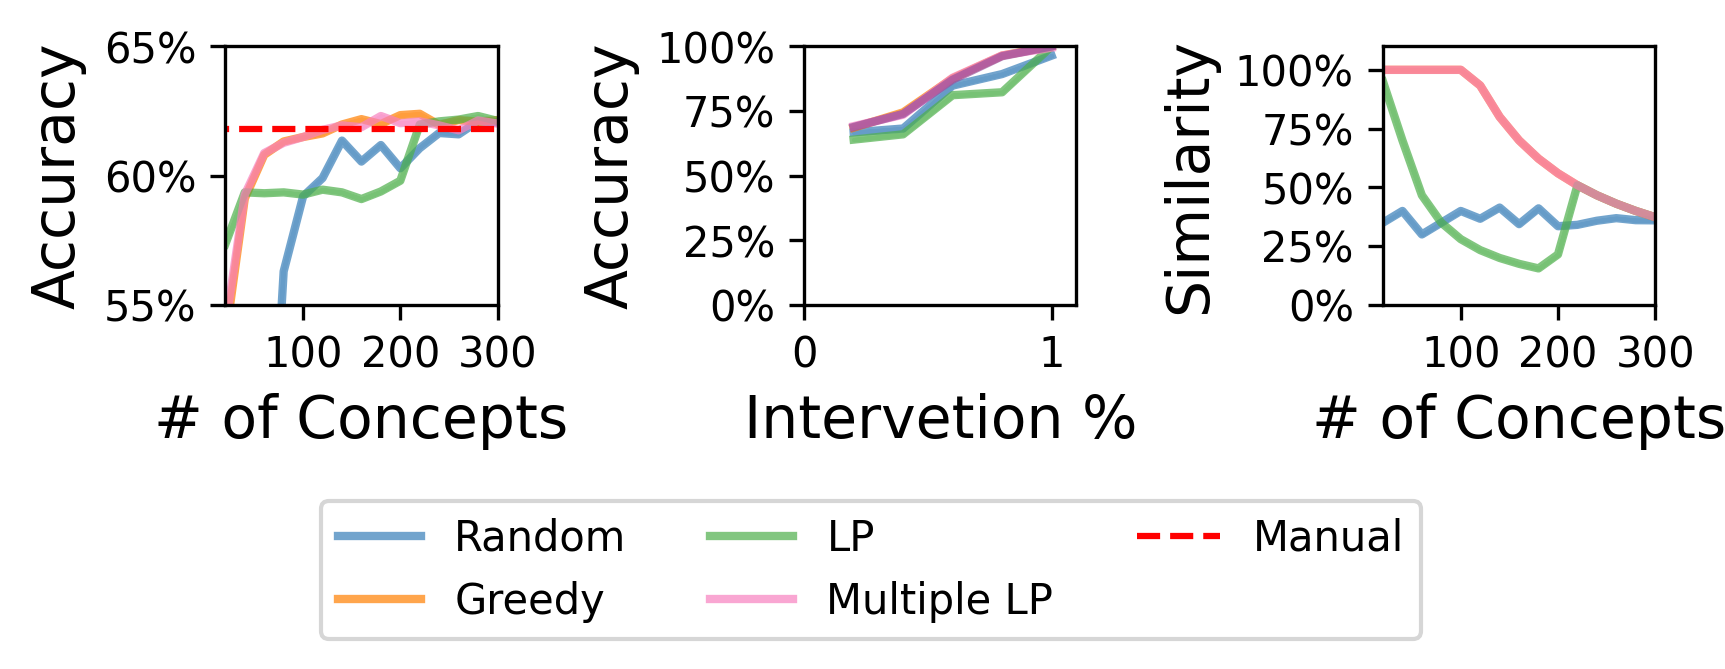

In [33]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,3)

sup_y_label = ""
overall_format = {'figsize':(6,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_lim': [[[20,300],[0,1.1],[20,300]]],
    'y_lim': [[[0.55,0.65],[0,1],[0,1.1]]],
    'y_ticks': [[[[0.55,0.6,0.65],["55%","60%","65%"]],[[0,0.25,0.5,0.75,1],["0%","25%","50%","75%","100%"]],[[0,0.25,0.5,0.75,1],["0%","25%","50%","75%","100%"]]]],
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts","Intervetion %","# of Concepts"]],y_labels=[["Accuracy","Accuracy","Similarity"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Random","Greedy","LP","Multiple LP"]

x_groups = [list(range(20,311,20)) for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(arr)-1)] for i in range(len(x_groups[0]))] for arr in [random_selection,greedy,imperfect_lp,multiple_lp]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
ax[0][0].hlines(chosen_concepts,0,311,label="Manual",color="red",linestyle="--")
line_format = {'color_palette': 'six_color', 'linewidth': 2}

all_labels = ["Random","Greedy","LP","Multiple LP","Manual"]

x_groups = [[0.2,0.4,0.6,0.8,1.0] for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(arr)-1)] for i in range(len(x_groups[0]))] for arr in [random_selection_intervention,greedy_intervention,imperfect_lp_intervention,multiple_lp_intervention,chosen_concepts_intervention]]

plot_line(ax[0][1],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)


all_labels = ["Random","Greedy","LP","Multiple LP"]

x_groups = [list(range(20,311,20)) for i in range(len(all_labels))]
y_vals = [[arr[min(i,len(similarity)-1)] for i in range(len(x_groups[0]))] for arr in [similarity_random,similarity_greedy,similarity,similarity_multiple]]

plot_line(ax[0][2],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)
legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 3, 'bbox_to_anchor': (0.2,-0.2),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_cub.pdf",dpi=300, bbox_inches='tight')